# 04. LPIPS Dataset Comparison

This notebook compares several datasets while keeping the model family the same.

Questions answered here:

- Does LPIPS vs MSE change across datasets?
- Is behaviour on CIFAR10 different from CIFAR100 or STL10?
- What happens if we add a face dataset like CelebA?


In [ ]:
!pip install torch torchvision lpips matplotlib pandas pillow seaborn

import io
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset

import lpips

sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "generated_figures"
FIG_DIR.mkdir(exist_ok=True)
print("Using device:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.9 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# Reproducibility helps make LPIPS-vs-MSE comparisons fair.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
STL10_CLASSES = CIFAR10_CLASSES

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def to_lpips_range(x):
    return x * 2.0 - 1.0


def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2, dim=(1, 2, 3))
    return 10.0 * torch.log10(1.0 / (mse + 1e-8))


def build_transform(image_size: int):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
    ])


def degrade_image(image: torch.Tensor, mode: str):
    image = image.clone()
    if mode == "identity":
        return image
    if mode == "gaussian_noise":
        noise = 0.08 * torch.randn_like(image)
        return torch.clamp(image + noise, 0.0, 1.0)
    if mode == "blur":
        return TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[1.2, 1.2])
    if mode == "downsample":
        h, w = image.shape[-2:]
        small = TF.resize(image, [max(8, h // 4), max(8, w // 4)], antialias=True)
        return TF.resize(small, [h, w], antialias=True)
    if mode == "shift":
        return torch.roll(image, shifts=(2, 2), dims=(1, 2))
    raise ValueError(f"Unknown degradation mode: {mode}")


class ReconstructionWrapper(Dataset):
    def __init__(self, base_dataset, degradation="identity"):
        self.base_dataset = base_dataset
        self.degradation = degradation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        image = sample[0] if isinstance(sample, tuple) else sample
        degraded = degrade_image(image, self.degradation)
        return degraded, image


class RepeatedSingleImageDataset(Dataset):
    def __init__(self, image: torch.Tensor, repeats=256, degradation="identity"):
        self.image = image
        self.repeats = repeats
        self.degradation = degradation

    def __len__(self):
        return self.repeats

    def __getitem__(self, idx):
        return degrade_image(self.image, self.degradation), self.image


def get_dataset(dataset_name: str, image_size: int):
    transform = build_transform(image_size)
    name = dataset_name.upper()
    if name == "CIFAR10":
        return torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "CIFAR100":
        return torchvision.datasets.CIFAR100(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "STL10":
        return torchvision.datasets.STL10(root=str(DATA_DIR), split="train", download=True, transform=transform)
    if name == "CELEBA":
        return torchvision.datasets.CelebA(root=str(DATA_DIR), split="train", download=True, transform=transform)
    raise ValueError(f"Unsupported dataset: {dataset_name}")


def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return [int(x) for x in dataset.targets]
    if hasattr(dataset, "labels"):
        return [int(x) for x in dataset.labels]
    return None


def filter_by_class(dataset, dataset_name: str, class_name: str, max_items=1000):
    if class_name == "all":
        return dataset
    targets = get_targets(dataset)
    if targets is None:
        raise ValueError(f"Dataset {dataset_name} does not expose simple class labels for filtering.")
    if dataset_name.upper() == "CIFAR10":
        class_index = CIFAR10_CLASSES.index(class_name)
    elif dataset_name.upper() == "STL10":
        class_index = STL10_CLASSES.index(class_name)
    else:
        raise ValueError(f"Class filtering not set up for {dataset_name}.")
    indices = [i for i, target in enumerate(targets) if target == class_index][:max_items]
    return Subset(dataset, indices)


def train_two_models(train_loader, epochs=5, lpips_net="vgg"):
    base_model = ConvAutoencoder().to(DEVICE)
    model_lpips = ConvAutoencoder().to(DEVICE)
    model_mse = ConvAutoencoder().to(DEVICE)
    model_lpips.load_state_dict(base_model.state_dict())
    model_mse.load_state_dict(base_model.state_dict())

    optimizer_lpips = optim.Adam(model_lpips.parameters(), lr=1e-4)
    optimizer_mse = optim.Adam(model_mse.parameters(), lr=1e-4)
    lpips_loss = lpips.LPIPS(net=lpips_net).to(DEVICE).eval()
    mse_loss = nn.MSELoss()

    history = {"epoch": [], "lpips_train_loss": [], "mse_train_loss": []}
    for epoch in range(1, epochs + 1):
        model_lpips.train()
        model_mse.train()
        running_lpips = 0.0
        running_mse = 0.0
        batches = 0

        for degraded, clean in train_loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)

            optimizer_lpips.zero_grad()
            pred_lpips = model_lpips(degraded)
            loss_lp = lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean()
            loss_lp.backward()
            optimizer_lpips.step()

            optimizer_mse.zero_grad()
            pred_mse = model_mse(degraded)
            loss_mse = mse_loss(pred_mse, clean)
            loss_mse.backward()
            optimizer_mse.step()

            running_lpips += loss_lp.item()
            running_mse += loss_mse.item()
            batches += 1

        history["epoch"].append(epoch)
        history["lpips_train_loss"].append(running_lpips / batches)
        history["mse_train_loss"].append(running_mse / batches)
        print(f"Epoch {epoch:02d} | LPIPS: {history['lpips_train_loss'][-1]:.4f} | MSE: {history['mse_train_loss'][-1]:.4f}")

    return model_lpips, model_mse, pd.DataFrame(history), lpips_loss, mse_loss


def evaluate_models(model_lpips, model_mse, loader, lpips_loss, mse_loss):
    model_lpips.eval()
    model_mse.eval()
    rows = []
    with torch.no_grad():
        for degraded, clean in loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)
            pred_lpips = model_lpips(degraded)
            pred_mse = model_mse(degraded)
            rows.append({
                "lpips_model_lpips": lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean().item(),
                "mse_model_lpips": lpips_loss(to_lpips_range(pred_mse), to_lpips_range(clean)).mean().item(),
                "lpips_model_mse": mse_loss(pred_lpips, clean).item(),
                "mse_model_mse": mse_loss(pred_mse, clean).item(),
                "lpips_model_psnr": psnr(pred_lpips, clean).mean().item(),
                "mse_model_psnr": psnr(pred_mse, clean).mean().item(),
            })
    return pd.DataFrame(rows).mean().to_frame(name="value")


def show_reconstructions(model_lpips, model_mse, loader, title, n=5):
    degraded, clean = next(iter(loader))
    degraded = degraded.to(DEVICE)
    clean = clean.to(DEVICE)
    with torch.no_grad():
        pred_lpips = model_lpips(degraded).cpu()
        pred_mse = model_mse(degraded).cpu()
    degraded = degraded.cpu()
    clean = clean.cpu()

    n = min(n, degraded.size(0))
    plt.figure(figsize=(3 * n, 8))
    for i in range(n):
        plt.subplot(4, n, i + 1)
        plt.imshow(degraded[i].permute(1, 2, 0))
        plt.title("Input")
        plt.axis("off")

        plt.subplot(4, n, n + i + 1)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.title("Target")
        plt.axis("off")

        plt.subplot(4, n, 2 * n + i + 1)
        plt.imshow(pred_lpips[i].permute(1, 2, 0))
        plt.title("LPIPS")
        plt.axis("off")

        plt.subplot(4, n, 3 * n + i + 1)
        plt.imshow(pred_mse[i].permute(1, 2, 0))
        plt.title("MSE")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
DATASETS_TO_TEST = ["CIFAR10", "CIFAR100", "STL10"]
# If CelebA works in your environment, add it to the list above.
IMAGE_SIZE = 64
DEGRADATION = "blur"
TRAIN_SAMPLES = 256
VAL_SAMPLES = 64
BATCH_SIZE = 32
EPOCHS = 100
LPIPS_NET = "vgg"


In [ ]:
dataset_rows = []
dataset_examples = {}

for dataset_name in DATASETS_TO_TEST:
    print("\nRunning dataset:", dataset_name)
    dataset = get_dataset(dataset_name, IMAGE_SIZE)
    indices = list(range(min(len(dataset), TRAIN_SAMPLES + VAL_SAMPLES)))
    train_indices = indices[:TRAIN_SAMPLES]
    val_indices = indices[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
    if len(val_indices) == 0:
        val_indices = indices[:min(VAL_SAMPLES, len(indices))]

    train_dataset = ReconstructionWrapper(Subset(dataset, train_indices), degradation=DEGRADATION)
    val_dataset = ReconstructionWrapper(Subset(dataset, val_indices), degradation=DEGRADATION)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model_lpips, model_mse, history_df, lpips_loss, mse_loss = train_two_models(train_loader, epochs=EPOCHS, lpips_net=LPIPS_NET)
    metrics = evaluate_models(model_lpips, model_mse, val_loader, lpips_loss, mse_loss)

    dataset_rows.append({
        "dataset": dataset_name,
        "lpips_model_lpips": metrics.loc["lpips_model_lpips", "value"],
        "mse_model_lpips": metrics.loc["mse_model_lpips", "value"],
        "lpips_model_mse": metrics.loc["lpips_model_mse", "value"],
        "mse_model_mse": metrics.loc["mse_model_mse", "value"],
        "lpips_model_psnr": metrics.loc["lpips_model_psnr", "value"],
        "mse_model_psnr": metrics.loc["mse_model_psnr", "value"],
    })

    dataset_examples[dataset_name] = (model_lpips, model_mse, val_loader)

dataset_df = pd.DataFrame(dataset_rows)
dataset_df



Running dataset: CIFAR10


100%|██████████| 170M/170M [00:09<00:00, 17.4MB/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...

100%|██████████| 169M/169M [00:07<00:00, 22.2MB/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Epoch 01 | LPIPS: 0.7712 | MSE: 0.0670
Epoch 02 | LPIPS: 0.7667 | MSE: 0.0668
Epoch 03 | LPIPS: 0.7628 | MSE: 0.0664
Epoch 04 | LPIPS: 0.7610 | MSE: 0.0655
Epoch 05 | LPIPS: 0.7583 | MSE: 0.0635
Epoch 06 | LPIPS: 0.7552 | MSE: 0.0589
Epoch 07 | LPIPS: 0.7517 | MSE: 0.0507
Epoch 08 | LPIPS: 0.7467 | MSE: 0.0402
Epoch 09 | LPIPS: 0.7387 | MSE: 0.0286
Epoch 10 | LPIPS: 0.7281 | MSE: 0.0214
Epoch 11 | LPIPS: 0.7129 | MSE: 0.0185
Epoch 12 | LPIPS: 0.6960 | MSE: 0.0173
Epoch 13 | LPIPS: 0.6765 | MSE: 0.0162
Epoch 14 | LPIPS: 0.6604 | MSE: 0.0158
Epoch 15 | LPIPS: 0.6510 | MSE: 0.0151
Epoch 16 | LPIPS: 0.6460 | MSE: 0.0149
Epoch 17 | LPIPS: 0.6422 | MSE: 0.0147
Epoch 18 | LPIPS: 0.6396 | MSE: 0.0144
Epoch 19 | LPIPS: 0.6369 | MSE: 0.0140
Epoch 20 | LPIPS: 0.6347 | MSE: 0.0138
Epoch 21 | LPIPS: 0.6308 | MSE: 0.0136
Epoch 22 | LPIPS: 0.630

100%|██████████| 2.64G/2.64G [03:37<00:00, 12.2MB/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Epoch 01 | LPIPS: 0.7859 | MSE: 0.0685
Epoch 02 | LPIPS: 0.7740 | MSE: 0.0682
Epoch 03 | LPIPS: 0.7656 | MSE: 0.0677
Epoch 04 | LPIPS: 0.7590 | MSE: 0.0670
Epoch 05 | LPIPS: 0.7493 | MSE: 0.0657
Epoch 06 | LPIPS: 0.7382 | MSE: 0.0628
Epoch 07 | LPIPS: 0.7254 | MSE: 0.0569
Epoch 08 | LPIPS: 0.7115 | MSE: 0.0454
Epoch 09 | LPIPS: 0.7018 | MSE: 0.0306
Epoch 10 | LPIPS: 0.6942 | MSE: 0.0223
Epoch 11 | LPIPS: 0.6892 | MSE: 0.0212
Epoch 12 | LPIPS: 0.6858 | MSE: 0.0196
Epoch 13 | LPIPS: 0.6832 | MSE: 0.0187
Epoch 14 | LPIPS: 0.6810 | MSE: 0.0181
Epoch 15 | LPIPS: 0.6785 | MSE: 0.0177
Epoch 16 | LPIPS: 0.6763 | MSE: 0.0173
Epoch 17 | LPIPS: 0.6746 | MSE: 0.0170
Epoch 18 | LPIPS: 0.6732 | MSE: 0.0166
Epoch 19 | LPIPS: 0.6709 | MSE: 0.0163
Epoch 20 | LPIPS: 0.6691 | MSE: 0.0161
Epoch 21 | LPIPS: 0.6675 | MSE: 0.0157
Epoch 22 | LPIPS: 0.665

,dataset,lpips_model_lpips,mse_model_lpips,lpips_model_mse,mse_model_mse,lpips_model_psnr,mse_model_psnr
0,CIFAR10,0.288883,0.344529,0.059015,0.002792,12.687571,26.196673
1,CIFAR100,0.199126,0.373416,0.033467,0.003766,15.348655,25.011505
2,STL10,0.410918,0.460131,0.065280,0.005865,12.171855,22.622995


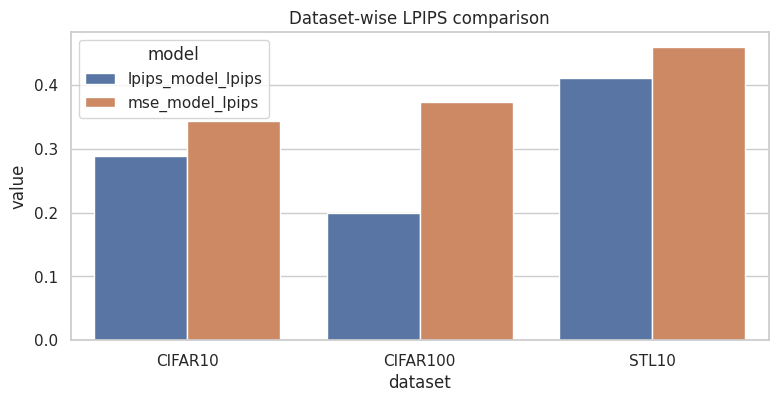

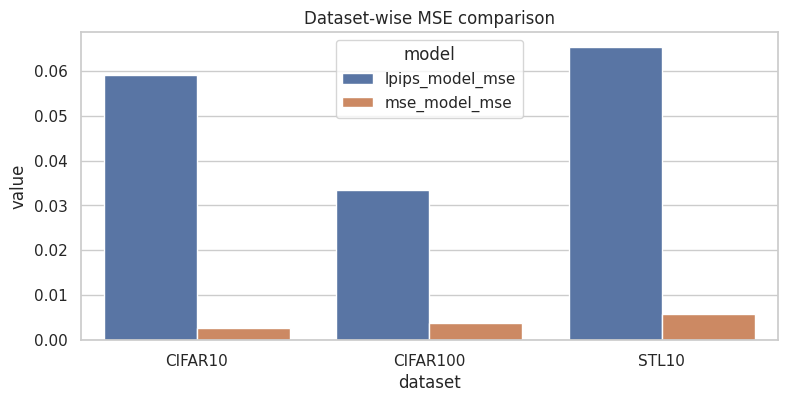

In [ ]:
# Compare LPIPS score by dataset.
plot_df = dataset_df.melt(
    id_vars="dataset",
    value_vars=["lpips_model_lpips", "mse_model_lpips"],
    var_name="model",
    value_name="value",
)
plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x="dataset", y="value", hue="model")
plt.title("Dataset-wise LPIPS comparison")
plt.show()

# Compare MSE score by dataset.
plot_df = dataset_df.melt(
    id_vars="dataset",
    value_vars=["lpips_model_mse", "mse_model_mse"],
    var_name="model",
    value_name="value",
)
plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x="dataset", y="value", hue="model")
plt.title("Dataset-wise MSE comparison")
plt.show()


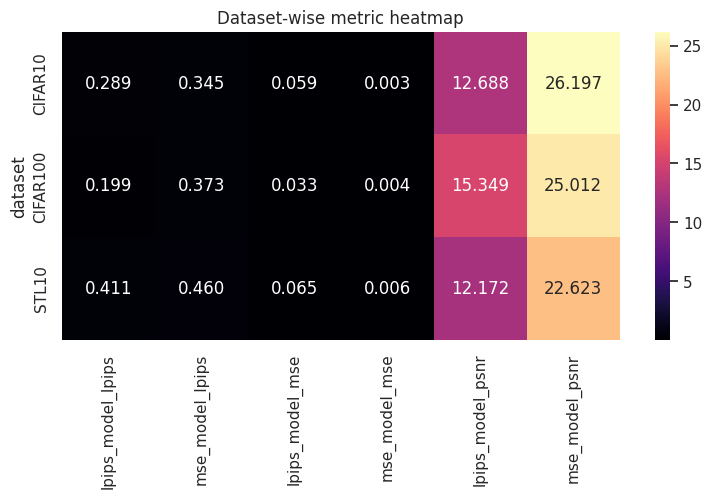

In [ ]:
plt.figure(figsize=(9, 4))
heatmap_df = dataset_df.set_index("dataset")
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="magma")
plt.title("Dataset-wise metric heatmap")
plt.show()


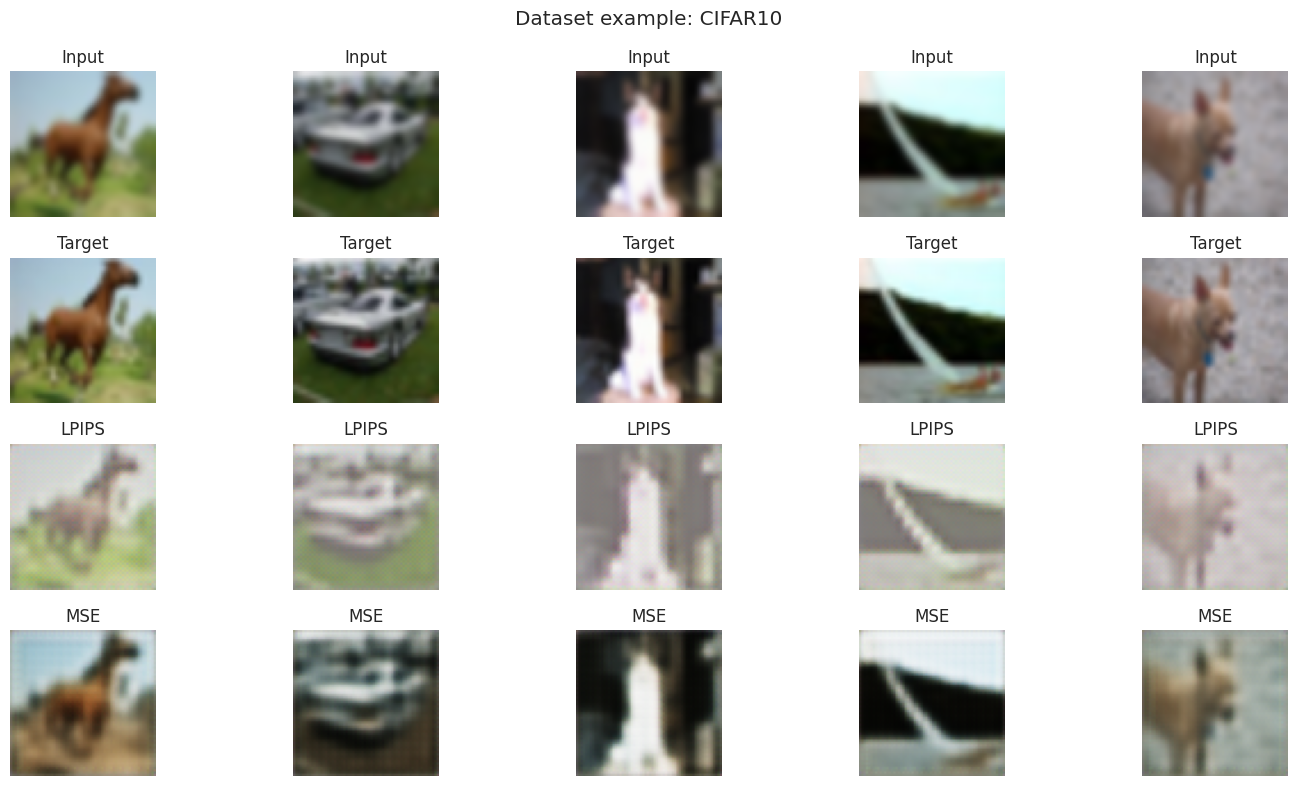

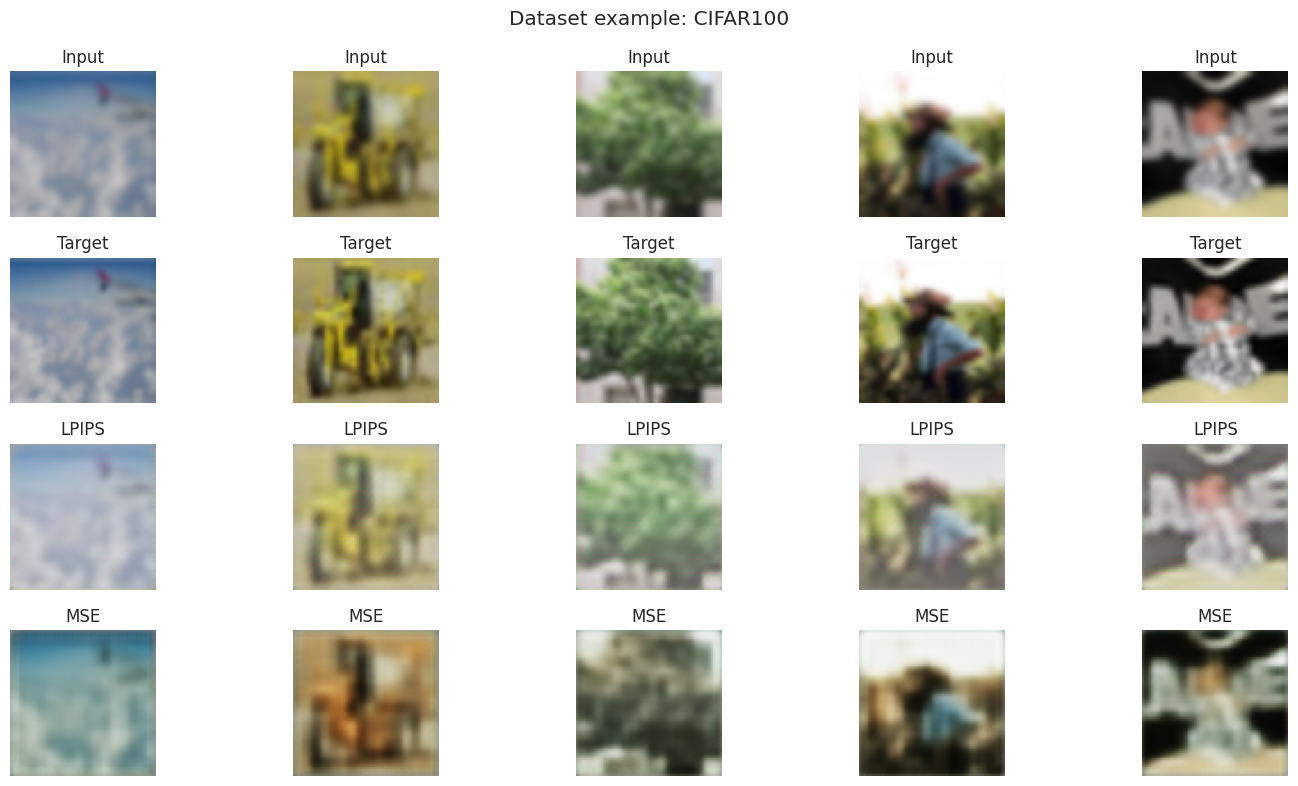

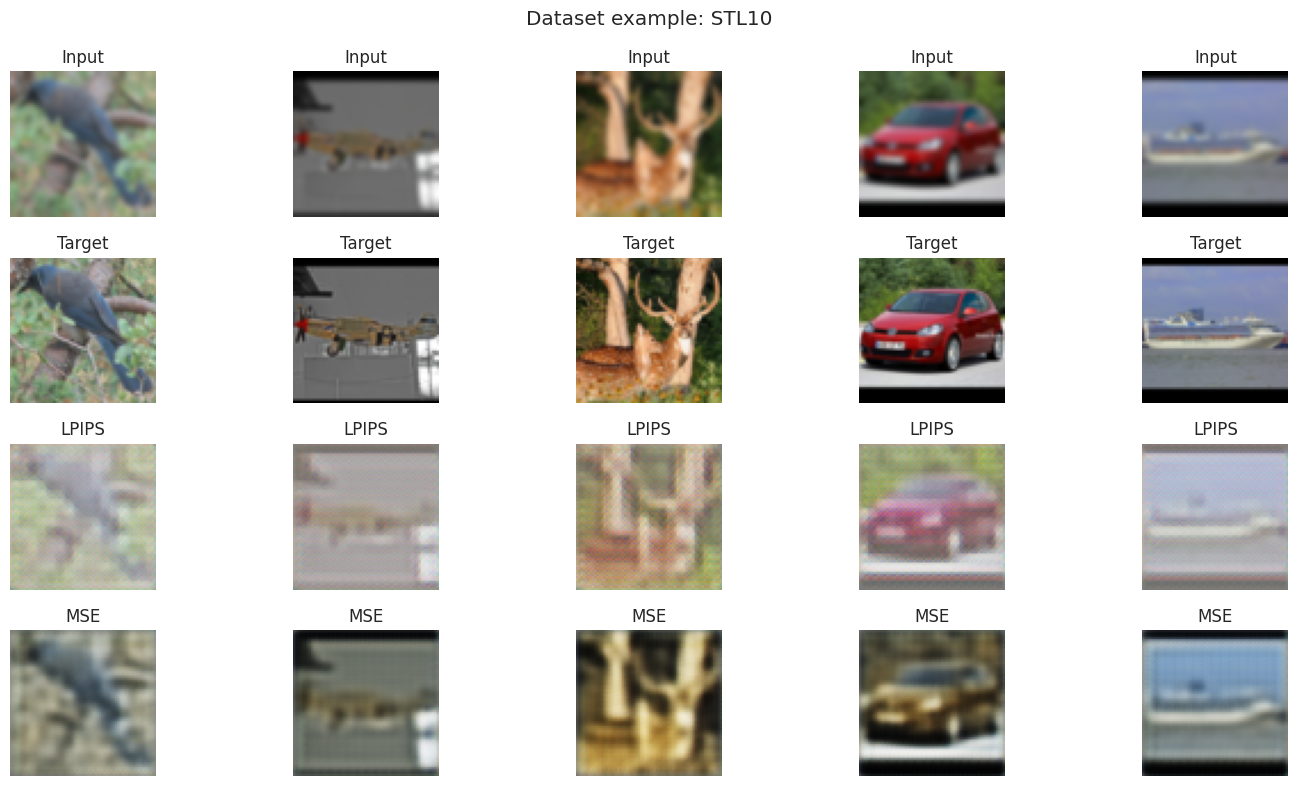

In [ ]:
# Show one reconstruction grid per dataset.
for dataset_name, (model_lpips, model_mse, val_loader) in dataset_examples.items():
    show_reconstructions(model_lpips, model_mse, val_loader, title=f"Dataset example: {dataset_name}")
